In [1]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import random
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from torch import nn
import math
from torch.utils.data import Dataset
import itertools

In [2]:
def get_all_files_in_directory(directory):
    # 存储文件路径的数组
    file_paths = []
    
    # 遍历目录及子目录
    for root, dirs, files in os.walk(directory):
        for file in files:
            if '.ipynb_checkpoints' in root:
                continue
            # 获取文件的完整路径
            file_paths.append(os.path.join(root, file))
    
    return file_paths

# 文件夹路径
directory = 'homeA-mapped'  

# 获取所有文件的路径
file_paths = get_all_files_in_directory(directory)


In [3]:

# 读取 Excel 文件

Data_startp=40*15+1
Data_endp=40*17+1  #Data_length
Data_shift=40  #Data_length
Data_lift=100
Data_norm_fac=500
Data_input_list=[];
Data_target_list=[];
for i_f in range(len(file_paths)):
    file_path = file_paths[i_f]
    df = pd.read_csv(file_path)
    for i_s in  range(-Data_shift,Data_shift+1):
        Data_t=df.iloc[0,Data_startp:Data_endp].to_numpy();
        Data_Dev1=df.iloc[9,Data_startp+i_s:Data_endp+i_s].to_numpy();
        Data_Dev2=df.iloc[21,Data_startp+i_s:Data_endp+i_s].to_numpy();
        Data_Dev1=Data_Dev1.astype(np.float32)+Data_lift
        Data_Dev2=Data_Dev2.astype(np.float32)+Data_lift
        Data_Dev1=Data_Dev1/Data_norm_fac
        Data_Dev2=Data_Dev2/Data_norm_fac
        Data_total=Data_Dev1+Data_Dev2;
        Data_input_list.append(Data_total)
        Data_target_list.append( np.concatenate((Data_Dev1,Data_Dev2)))


In [4]:
class CustomDataset(Dataset):
    def __init__(self, inputs, targets, transform=None):
        """
        初始化数据集
        :param inputs: 输入数据列表或数组
        :param targets: 目标标签列表或数组
        :param transform: 可选的变换操作
        """
        self.inputs = inputs
        self.targets = targets
        self.transform = transform

    def __len__(self):
        # 返回数据集的长度
        return len(self.inputs)

    def __getitem__(self, idx):
        # 获取指定索引的数据和标签
        input_data = self.inputs[idx]
        target_data = self.targets[idx]
        
        # 如果指定了 transform，对 input_data 进行处理
        if self.transform:
            input_data = self.transform(input_data)
        
        return input_data, target_data

In [5]:
# 创建数据集实例
dataset = CustomDataset(Data_input_list, Data_target_list)
train_size=split_index = int(0.85 * len(Data_input_list))
test_size=len(Data_input_list)-train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 500

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)



In [6]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(80, 320),
            nn.ReLU(),
            nn.Linear(320, 320),
            nn.ReLU(),
            nn.Linear(320, 2*80)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        # logits=torch.tensor(logits)
        return logits
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=80, out_features=320, bias=True)
    (1): ReLU()
    (2): Linear(in_features=320, out_features=320, bias=True)
    (3): ReLU()
    (4): Linear(in_features=320, out_features=160, bias=True)
  )
)


In [94]:
loss_fn = nn.L1Loss()
loss_fn1 = nn.CrossEntropyLoss()
def manhattan_loss(x1, x2):
    return torch.sum(torch.abs(x1 - x2))
# loss_fn = manhattan_loss()

optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
def train(dataloader, model, loss_fn, optimizer):  #, loss_fn
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        
        # X = torch.tensor(X.astype(np.float64))
        # y = torch.tensor(y.astype(np.float64))
        X, y = X.to(device), y.to(device)
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if batch % 500 == 0:
        #     loss, current = loss.item(), (batch + 1) * len(X)
        #     print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [8]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: \n  Avg loss: {test_loss:>8f} \n")

In [96]:
epochs = 200
for t in range(epochs):

    train(train_dataloader, model, loss_fn,  optimizer) #loss_fn,
    if t % 100 == 0:
        print(f"Epoch {t+1}\n-------------------------------")
        test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
  Avg loss: 0.124324 

Epoch 101
-------------------------------
Test Error: 
  Avg loss: 0.124220 

Done!


In [10]:
# for batch, (X, y) in itertools.islice(enumerate(train_dataloader), 1):
#     aa=X
#     # aa.requires_grad_()
#     # print(y)
#     # print(f" Batch: {batch[0][1]}")  #Index: {index},
# # loss_fn(model(aa),y)
# loss_fn1(model(aa),y)
# model(aa[0:1])


Text(0.5, 1.0, 'test_dataset')

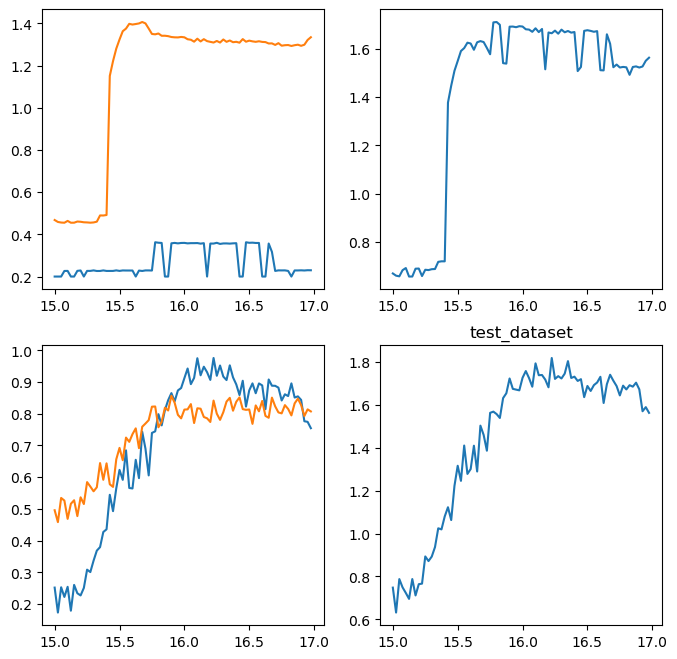

In [102]:
data_num=random.randint(0, len(test_dataset))
X_in=test_dataset[data_num]
figure = plt.figure(figsize=(8, 8))
Data_total=test_dataset[data_num][0]
Data_Dev1=test_dataset[data_num][1][0:80]
Data_Dev2=test_dataset[data_num][1][80:160]

figure.add_subplot(2, 2, 1)
plt.plot(Data_t,Data_Dev1)
plt.plot(Data_t,Data_Dev2)
figure.add_subplot(2, 2, 2)
plt.plot(Data_t,Data_total)

XX=torch.tensor(test_dataset[data_num][0]).reshape(1, 80)
pred=model(XX)
figure.add_subplot(2, 2, 3)
pred_1=pred[0,0:80].detach().numpy()
pred_2=pred[0,80:160].detach().numpy()
plt.plot(Data_t,pred_1)
plt.plot(Data_t,pred_2)
figure.add_subplot(2, 2, 4)
plt.plot(Data_t,pred_1+pred_2)
plt.title("test_dataset")



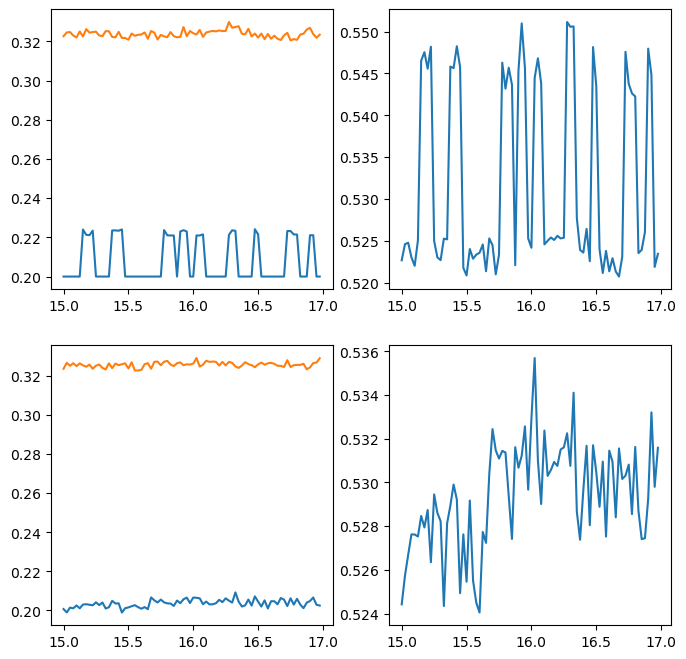

In [104]:
data_num=random.randint(0, len(test_dataset))
X_in=train_dataset[data_num]
figure = plt.figure(figsize=(8, 8))
Data_total=train_dataset[data_num][0]
Data_Dev1=train_dataset[data_num][1][0:80]
Data_Dev2=train_dataset[data_num][1][80:160]

figure.add_subplot(2, 2, 1)
plt.plot(Data_t,Data_Dev1)
plt.plot(Data_t,Data_Dev2)
figure.add_subplot(2, 2, 2)
plt.plot(Data_t,Data_total)

XX=torch.tensor(train_dataset[data_num][0]).reshape(1, 80)
pred=model(XX)
figure.add_subplot(2, 2, 3)
pred_1=pred[0,0:80].detach().numpy()
pred_2=pred[0,80:160].detach().numpy()
plt.plot(Data_t,pred_1)
plt.plot(Data_t,pred_2)
figure.add_subplot(2, 2, 4)
plt.plot(Data_t,pred_1+pred_2)



# train_dataset

In [100]:
# # data_num=random.randint(0, len(file_paths))
# len(test_dataset)

# Data_Dev2=Data_target_list[data_num]
# Data_Dev1=Data_Dev2[0:80]
# Data_Dev2=Data_Dev2[80:160]
# Data_total=Data_input_list[data_num]

# XX=torch.tensor(dataset[data_num][0]).reshape(1, 80)
# pred=model(XX)
# # Pred=model(data_num-1:data_num)
# figure = plt.figure(figsize=(8, 8))
# figure.add_subplot(2, 2, 1)
# plt.plot(Data_t,Data_Dev1)
# plt.plot(Data_t,Data_Dev2)
# figure.add_subplot(2, 2, 2)
# plt.plot(Data_t,XX[0,:].detach().numpy())
# figure.add_subplot(2, 2, 3)
# pred_1=pred[0,0:80].detach().numpy()
# pred_2=pred[0,80:160].detach().numpy()
# plt.plot(Data_t,pred_1)
# plt.plot(Data_t,pred_2)
# figure.add_subplot(2, 2, 4)
# plt.plot(Data_t,pred_1+pred_2)

# # plt.plot()

# plt.show()


In [14]:
# for batch, (X, y) in itertools.islice(enumerate(train_dataloader), 1):
#     aa=X
#     aa.requires_grad_()
#     # print(y)
#     # print(f" Batch: {batch[0][1]}")  #Index: {index},
# # loss_fn(model(aa),y)
# loss_fn1(model(aa),y)
# X[0].shape
# X[0:1]
# model(X[0:1])
# # model()
# XX1=XX[0:1]
# XX=torch.tensor(dataset[0][0]).reshape(1, 80)
# model(XX)
# # model(XX)
# # print(XX.shape)
# # print(X[0:1].shape)

In [15]:



# # 设置 Excel 文件路径
# data_num=random.randint(0, len(file_paths))
# print(data_num)
# file_path = file_paths[data_num]  #'homeA-mapped/2012-Jul-10.csv'

# # 读取 Excel 文件
# df = pd.read_csv(file_path)
# # 打印读取的数据
# # print(df.head())
# Data_length = df.iloc[0].shape[0]
# Data_startp=40*15+1
# Data_endp=40*17+1  #Data_length
# # Data_startp=1
# # Data_endp=Data_length


# Data_t=df.iloc[0,Data_startp:Data_endp].to_numpy();
# Data_Dev1=df.iloc[9,Data_startp:Data_endp].to_numpy();
# Data_Dev2=df.iloc[21,Data_startp:Data_endp].to_numpy();
# figure = plt.figure(figsize=(8, 4))
# figure.add_subplot(1, 2, 1)
# plt.plot(Data_t,Data_Dev1)
# plt.plot(Data_t,Data_Dev2)
# figure.add_subplot(1, 2, 2)
# plt.plot(Data_t,Data_Dev1+Data_Dev2)
# plt.show()
